# Usage Demo

## Import all modules and libraries

The FR module itself only needs `pytorch`, `torchvision`, and `pyyaml` to run.

When running with MPS, you may need to set the environment variable `PYTORCH_ENABLE_MPS_FALLBACK=1` to allow fallback to CPU for unsupported operations like `grid_sample`. You can set it in the terminal before running the demo, or set it in the notebook as below. Note that the setting must be done before importing `torch`. On initialization, the `FR` module will automatically set this environment variable, but it only takes effect if you import `FR` before `torch`.

When running with CUDA, you may want to set `torch.backends.cudnn.benchmark = True` and `torch.backends.cudnn.deterministic = False` to improve performance, as shown below.

In [1]:
import os; os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
from PIL import Image
import numpy as np

import frbench
from frbench import FR

## Init the model and load the images

The FR module expects the input images to be **[B, 3, H, W] or [3, H, W]**, **float**, and **RGB** tensors in the **[0, 255]** range.

Model itself usually expects cropped (optimally aligned) image tensors with shape [B, 3, 112, 112], RGB, float, and in the [-1, 1] range. The FR module will automatically do the necessary preprocessing to convert the input images to the expected format.

The input images can be uncropped. If so, you will need to set `need_crop=True` (and optimally `need_align=True`) when using the forward method. The FR module will differentiably crop (and align) the input images. For more settings on cropping and alignment, including how to handle images with multiple faces or without faces, please refer to the `forward` method's docstring. In the demo, we will use the default settings, which will crop and align the largest face in each image.

In [2]:
# Choose the device to run the model on: CUDA (GPU), MPS (Apple Silicon GPU), or CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

# Load the images and convert them to tensors
def to_tensor(img_path: str) -> torch.Tensor:
    img_pil = Image.open(img_path) # PIL image in its native mode
    img_pil = img_pil.convert("RGB") # RGB, uint8, [0, 255], [H, W, 3]
    img_np = np.array(img_pil) # RGB, uint8, [0, 255], [H, W, 3]
    img_tensor = torch.tensor(img_np).to(device) # RGB, uint8, [0, 255], [H, W, 3]
    img_tensor = img_tensor.permute(2, 0, 1)
    img_tensor = img_tensor.unsqueeze(0).float() # RGB, float32, [0, 255], [1, 3, H, W], 
    return img_tensor

img1 = to_tensor("assets/cooper1.jpg")
img2 = to_tensor("assets/cooper2.jpg")
img3 = to_tensor("assets/grant.jpg")

# Initialize the model and load it to the device. A small model MobileViTv3-S is used here for demonstration purposes.
# See the README for the model options. The model will be downloaded automatically if not found in the cache.
fr = FR(backbone_type="mobilevitv3-s", loss_type="arcface", dataset_type="ms1m").to(device)

## Forward the model and get embeddings

`FR` accepts three different formats: one image of [3, H, W], one batch of [B, 3, H, W], or a list of single images of [3, H, W] or [1, 3, H, W]. For more information, see the `forward` docstring of `FR`.

In [3]:
# If all the images are of the same size, they can be stacked into a single tensor and passed to the model. Otherwise, they can be passed as a list of tensors.
result = fr.forward(imgs=[img1, img2, img3],
                    need_crop=True, need_align=True,
                    keep_largest=True, discard_invalid=False,
                    conf_thresh=0.8, iou_thresh=0.4, loosen_crop=1.,
                    tta=["flip_horizontal"], l2_normalize=False)

embeddings, indices, crops = result.embeddings, result.indices, result.crops

# `indices` is a list mapping each embedding back to its source image; make it a
# tensor so we can use boolean masks to gather the embeddings per image.
indices = torch.tensor(indices)
img1_embedding = embeddings[indices == 0] # [N1, D] Here N1 = 1 as only one face is kept for img1, and D = 512 for the MobileViTv3-S model.
img2_embedding = embeddings[indices == 1]
img3_embedding = embeddings[indices == 2]

Manifest not cached; downloading...


manifest.json: 100%|██████████| 16.4k/16.4k [00:00<00:00, 19.0MB/s]


Asset 'mobilevitv3-s_arcface_ms1m' not cached; downloading...


mobilevitv3-s_arcface_ms1m.tar.gz: 100%|██████████| 44.9M/44.9M [01:17<00:00, 609kB/s] 


Asset 'retinaface_mobilenetv1' not cached; downloading...


retinaface_mobilenetv1.tar.gz: 100%|██████████| 1.55M/1.55M [00:00<00:00, 5.04MB/s]


## Cosine Similarity Matrix

A simple demo here showing how to use the normalized embeddings to compute the cosine similarity matrix between all pairs of images. The cosine similarity is computed as the dot product of the normalized embeddings, which is equivalent to the cosine of the angle between the two vectors in the embedding space.

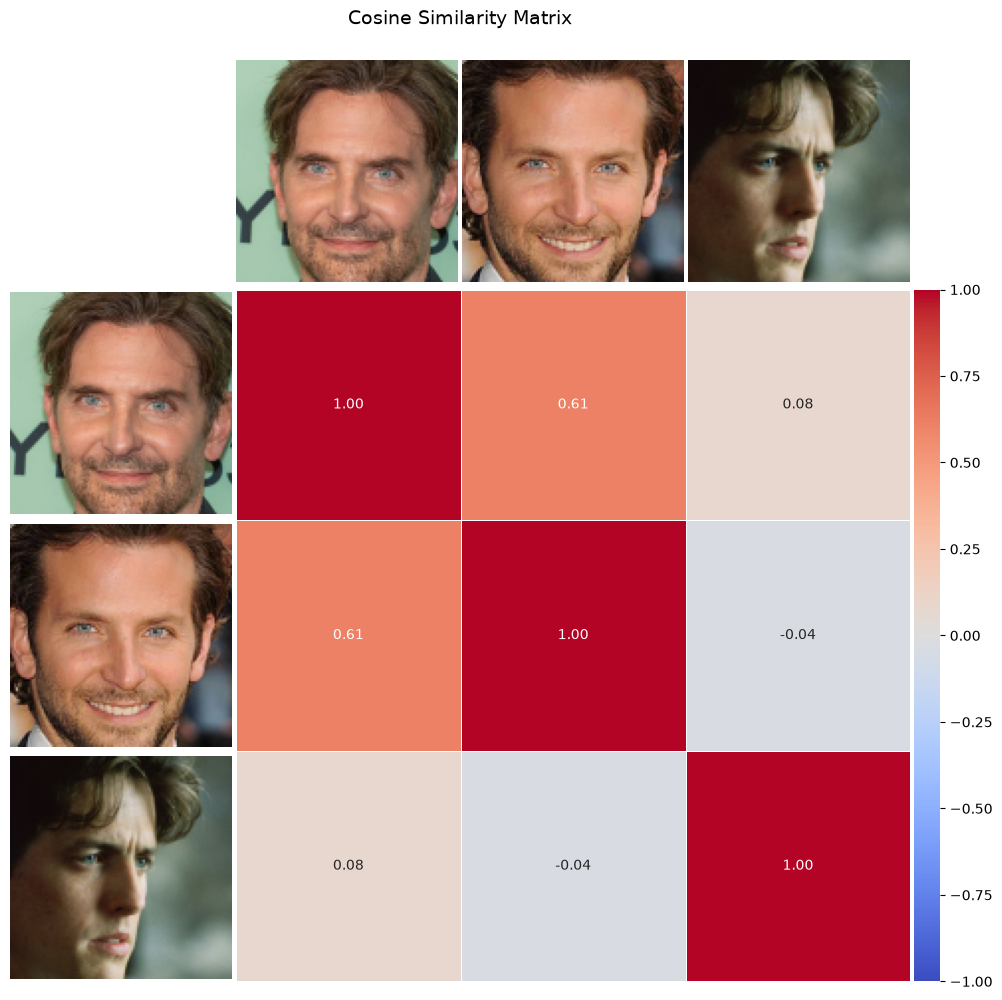

In [4]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

normalized_embeddings = F.normalize(embeddings, p=2, dim=1)
cosine_matrix = torch.mm(normalized_embeddings, normalized_embeddings.t())

# Visualization
matrix_np = cosine_matrix.detach().cpu().numpy()
def viz(preprocessed_imgs: torch.Tensor, mean: torch.Tensor, std: torch.Tensor, channel: str = "rgb") -> torch.Tensor:
        if channel == "bgr":
            preprocessed_imgs = preprocessed_imgs[:, [2, 1, 0], :, :]
        return (preprocessed_imgs * std + mean) * 255.0
crops_vis = viz(crops.detach(), mean=fr.preprocessor.mean, std=fr.preprocessor.std, channel=fr.preprocessor.channel).clamp(0., 255.).byte()
crops_vis = np.transpose(crops_vis.cpu().numpy(), (0, 2, 3, 1)) # [N, H, W, 3], RGB

N = len(crops_vis)
thumb_ratio = 3
cell_ratio = 3
cbar_ratio = 0.35 

fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(
    N + 1, N + 2,
    width_ratios=[thumb_ratio] + [cell_ratio] * N + [cbar_ratio],
    height_ratios=[thumb_ratio] + [cell_ratio] * N,
    hspace=0.02, wspace=0.02)
for i in range(N):
    ax = fig.add_subplot(gs[0, i + 1])
    ax.imshow(crops_vis[i])
    ax.axis('off')
for i in range(N):
    ax = fig.add_subplot(gs[i + 1, 0])
    ax.imshow(crops_vis[i])
    ax.axis('off')
ax_heatmap = fig.add_subplot(gs[1:, 1:N + 1])
cax = fig.add_subplot(gs[1:, N + 1])
sns.heatmap(matrix_np, annot=True, fmt=".2f", cmap="coolwarm",
            ax=ax_heatmap, cbar_ax=cax, xticklabels=False, yticklabels=False,
            vmin=-1, vmax=1, linewidths=0.5)
fig.suptitle("Cosine Similarity Matrix", fontsize=14, y=0.92)
plt.show()


## End-to-end differentiability

We demonstrate the end-to-end differentiability of the whole `FR` module with a toy loss.

In [5]:
# Enable gradient tracking on the raw input images.
img1_grad = img1.clone().detach().requires_grad_(True)
img2_grad = img2.clone().detach().requires_grad_(True)
img3_grad = img3.clone().detach().requires_grad_(True)

# Detect once, then reuse detections during the optimization loop (skips re-detection).
dets = fr.detect([img1_grad, img2_grad, img3_grad])

# Run the full FR forward pass (crop → align → backbone) with gradient tracking.
# img1 / img2: same person (Cooper); img3: different person (Grant).
result_grad = fr.forward(
    imgs=[img1_grad, img2_grad, img3_grad],
    need_crop=True, need_align=True, keep_largest=True,
    discard_invalid=False, conf_thresh=0.8, iou_thresh=0.4, loosen_crop=1.,
    detections=dets,
)
embeddings_grad, indices_grad = result_grad.embeddings, result_grad.indices

indices_t = torch.tensor(indices_grad)
e1 = F.normalize(embeddings_grad[indices_t == 0], dim=-1)  # Cooper 1
e2 = F.normalize(embeddings_grad[indices_t == 1], dim=-1)  # Cooper 2
e3 = F.normalize(embeddings_grad[indices_t == 2], dim=-1)  # Grant

# Toy contrastive objective:
#   sim_pos  → 1  (same identity, pull together)
#   sim_neg  → -1 (different identity, push apart)
sim_pos = (e1 * e2).sum()   # positive pair: Cooper1 vs Cooper2
sim_neg = (e1 * e3).sum()   # negative pair: Cooper1 vs Grant
loss = (1.0 - sim_pos) + (1.0 + sim_neg)

print(f"sim_pos  (Cooper1 vs Cooper2) : {sim_pos.item():.4f}")
print(f"sim_neg  (Cooper1 vs Grant) : {sim_neg.item():.4f}")
print(f"Toy contrastive loss          : {loss.item():.4f}")

# Backpropagate through the entire pipeline.
loss.backward()

g1 = img1_grad.grad.norm().item()
g2 = img2_grad.grad.norm().item()
g3 = img3_grad.grad.norm().item()

print(f"\n∂loss/∂img1 (Cooper1) gradient norm : {g1:.6f}")
print(f"∂loss/∂img2 (Cooper2) gradient norm : {g2:.6f}")
print(f"∂loss/∂img3 (Grant) gradient norm : {g3:.6f}")

assert all(g > 0 for g in [g1, g2, g3]), "Some gradients are zero — differentiability broken!"
print("\n✓ All input-image gradients are non-zero.")
print("  The FR pipeline (crop → align → backbone) is fully end-to-end differentiable.")


sim_pos  (Cooper1 vs Cooper2) : 0.6117
sim_neg  (Cooper1 vs Grant) : 0.0782
Toy contrastive loss          : 1.4665

∂loss/∂img1 (Cooper1) gradient norm : 0.000494
∂loss/∂img2 (Cooper2) gradient norm : 0.000724
∂loss/∂img3 (Grant) gradient norm : 0.000465

✓ All input-image gradients are non-zero.
  The FR pipeline (crop → align → backbone) is fully end-to-end differentiable.


/Users/wangziling/miniconda3/envs/test_ptfr/lib/python3.12/site-packages/torch/autograd/graph.py:882: UserWarning: The operator 'aten::grid_sampler_2d_backward' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
